In [1]:
# 0. Library + Data Load

from pathlib import Path
import json
import numpy as np
import pandas as pd

OUT_DIR = Path("./nsduh_analysis_outputs")

DATA_DIR = OUT_DIR / "df_corrected_7970_with_gpt_profiles_embeddings.csv"

df_ml = pd.read_csv(DATA_DIR)

print("[OK] Loaded full corrected dataset")
print("Shape:", df_ml.shape)
print(df_ml.columns.tolist())

print("\nMissing predictive_profile:")
print(df_ml["predictive_profile"].isna().sum())

print("\nMissing predictive_embedding:")
print(df_ml["predictive_profile"].isna().sum())

print("\nYear distribution")
print(df_ml["year"].value_counts().sort_index())

print("\nTarget distribution:")
print(df_ml["cost_barrier"].value_counts())

print("n\Year x target:")
print(pd.crosstab(df_ml["year"], df_ml["cost_barrier"]))

print("n\Year x target normalized:")
print(
    pd.crosstab(
        df_ml["year"],
        df_ml["cost_barrier"],
        normalize="index"
    )
)

<>:30: SyntaxWarning: invalid escape sequence '\Y'
<>:33: SyntaxWarning: invalid escape sequence '\Y'
<>:30: SyntaxWarning: invalid escape sequence '\Y'
<>:33: SyntaxWarning: invalid escape sequence '\Y'
/tmp/ipykernel_3632716/497797173.py:30: SyntaxWarning: invalid escape sequence '\Y'
  print("n\Year x target:")
/tmp/ipykernel_3632716/497797173.py:33: SyntaxWarning: invalid escape sequence '\Y'
  print("n\Year x target normalized:")


[OK] Loaded full corrected dataset
Shape: (7970, 11)
['original_index', 'year', 'AGE3', 'NEWRACE2', 'IRINSUR4', 'substance_peer_support', 'mental_health_peer_support', 'cost_barrier', 'predictive_text', 'predictive_profile', 'predictive_embedding']

Missing predictive_profile:
0

Missing predictive_embedding:
0

Year distribution
year
2022    4210
2023    3760
Name: count, dtype: int64

Target distribution:
cost_barrier
0    4134
1    3836
Name: count, dtype: int64
n\Year x target:
cost_barrier     0     1
year                    
2022          2201  2009
2023          1933  1827
n\Year x target normalized:
cost_barrier         0         1
year                            
2022          0.522803  0.477197
2023          0.514096  0.485904


In [2]:
# 1. RAW/ GPT Embedding / Combined feature 

!pip install openai

In [3]:
# Build feature matrices

# GPT profile embedding
X_embed = np.vstack(
    df_ml["predictive_embedding"].apply(json.loads).values
).astype("float32")


# Target
y = df_ml["cost_barrier"].astype(int).values

# Raw structured features
raw_cols = [
    "year", 
    "AGE3",
    "IRINSUR4",
    "substance_peer_support",
    "mental_health_peer_support",
]

df_raw = df_ml[raw_cols].copy()

for col in raw_cols:
    df_raw[col] = df_raw[col].astype(str)

# Important:
# get_dummies should be fit on the full corrected dataset
# so train/test have identical one-hot columns.
X_raw_df = pd.get_dummies(df_raw, drop_first = False)
X_raw = X_raw_df.values.astype("float32")

# Combined features
X_combined = np.hstack([X_raw, X_embed]).astype("float32")

print("X_raw:", X_raw.shape)
print("X_embed:", X_embed.shape)
print("X_combined:", X_combined.shape)
print("y:", y.shape)
print("Target counts:", np.bincount(y))

X_raw: (7970, 19)
X_embed: (7970, 1536)
X_combined: (7970, 1555)
y: (7970,)
Target counts: [4134 3836]


In [4]:
# 2. Cross_year index

# Cross-year train/test indices
year_values = df_ml["year"].astype(int).values

idx_2022 = np.where(year_values == 2022)[0]
print(idx_2022)
idx_2023 = np.where(year_values == 2023)[0]
print(idx_2023)

print("2022 size:", len(idx_2022))
print("2023 size:", len(idx_2023))

print("\n2022 target counts:")
print(np.bincount(y[idx_2022]))

print("\n2023 target counts:")
print(np.bincount(y[idx_2023]))

[   0    1    2 ... 4207 4208 4209]
[4210 4211 4212 ... 7967 7968 7969]
2022 size: 4210
2023 size: 3760

2022 target counts:
[2201 2009]

2023 target counts:
[1933 1827]


In [5]:
# 3. Evaluation

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
import numpy as np
import pandas as pd

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception as e:
    HAS_XGB = False
    print("[INFO] XGBoost not available:", e)


def make_model(model_name):
    model_name = str(model_name).strip()

    if model_name == "Logistic Regression":
        return make_pipeline(
            StandardScaler(),
            LogisticRegression(
                max_iter=3000,
                solver="saga",
                class_weight="balanced",
                n_jobs=-1,
                random_state=42,
            )
        )

    if model_name == "Linear SVM":
        return make_pipeline(
            StandardScaler(),
            LinearSVC(
                class_weight="balanced",
                max_iter=5000,
                random_state=42,
            )
        )

    if model_name == "Ridge Classifier":
        return make_pipeline(
            StandardScaler(),
            RidgeClassifier(
                class_weight="balanced",
                random_state=42,
            )
        )

    if model_name == "Random Forest":
        return RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=5,
            n_jobs=-1,
            class_weight="balanced",
            random_state=42,
        )

    if model_name == "Extra Trees":
        return ExtraTreesClassifier(
            n_estimators=300,
            min_samples_leaf=5,
            n_jobs=-1,
            class_weight="balanced",
            random_state=42,
        )

    if model_name == "HistGradientBoosting":
        return HistGradientBoostingClassifier(
            max_iter=300,
            learning_rate=0.05,
            max_leaf_nodes=31,
            l2_regularization=0.01,
            random_state=42,
        )

    if model_name == "XGBoost":
        if not HAS_XGB:
            raise RuntimeError("XGBoost is not installed.")

        return XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="binary:logistic",
            eval_metric="logloss",   # 중요: logless 아님, logloss
            n_jobs=-1,
            random_state=42,
        )

    raise ValueError(f"Unknown model: {model_name}")


def get_score(model, X_test):
    """
    Return 1D continuous score for AUC.
    Handles predict_proba output correctly.
    """
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)

        # binary classifier: shape (n, 2)
        if proba.ndim == 2 and proba.shape[1] >= 2:
            return proba[:, 1]

        # sometimes shape (n, 1)
        return proba.ravel()

    if hasattr(model, "decision_function"):
        score = model.decision_function(X_test)
        return np.asarray(score).ravel()

    pred = model.predict(X_test)
    return np.asarray(pred).ravel()

In [6]:
# evaluate function

def evaluate_cross_year(
    experiment_name,
    model_name,
    feature_name,
    X,
    train_idx,
    test_idx,
    y,
    train_year=None,
    test_year=None,
):
    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = np.asarray(y[train_idx]).ravel()
    y_test = np.asarray(y[test_idx]).ravel()

    model = make_model(model_name)

    print(f"\n[INFO] {experiment_name} | {model_name} | {feature_name}")
    print("Train:", X_train.shape, "Test:", X_test.shape)
    print("Train target:", np.bincount(y_train.astype(int)))
    print("Test target:", np.bincount(y_test.astype(int)))

    model.fit(X_train, y_train)

    y_pred = np.asarray(model.predict(X_test)).ravel()
    y_score = np.asarray(get_score(model, X_test)).ravel()

    # sanity check
    print("y_test shape:", y_test.shape)
    print("y_pred shape:", y_pred.shape)
    print("y_score shape:", y_score.shape)

    result = {
        "Experiment": experiment_name,
        "Train Year": train_year,
        "Test Year": test_year,
        "Model": model_name,
        "Feature": feature_name,
        "AUC": roc_auc_score(y_test, y_score),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "Train Size": len(train_idx),
        "Test Size": len(test_idx),
        "Train Pos Rate": y_train.mean(),
        "Test Pos Rate": y_test.mean(),
    }

    print(result)
    return result

In [7]:
# 4. Cross-year transfer

feature_sets = {
    "Raw structured": X_raw,
    "GPT profile embedding": X_embed,
    "Raw + GPT profile embedding": X_combined,
}

model_names = [
    "Logistic Regression",
    "Random Forest",
    "Extra Trees",
    "HistGradientBoosting",
]

if HAS_XGB:
    model_names.append("XGBoost")

experiments = [
    {
        "name": "Train 2022 -> Test 2023",
        "train_idx": idx_2022,
        "test_idx": idx_2023,
        "train_year": 2022,
        "test_year": 2023,
    },
    {
        "name": "Train 2023 -> Test 2022",
        "train_idx": idx_2023,
        "test_idx": idx_2022,
        "train_year": 2023,
        "test_year": 2022,
    },
]

cross_year_results = []

for exp in experiments:
    train_idx_exp = np.asarray(exp["train_idx"])
    test_idx_exp = np.asarray(exp["test_idx"])

    print("\n" + "=" * 100)
    print(exp["name"])
    print("Train size:", len(train_idx_exp))
    print("Test size:", len(test_idx_exp))
    print("Train target counts:", np.bincount(y[train_idx_exp].astype(int)))
    print("Test target counts:", np.bincount(y[test_idx_exp].astype(int)))
    print("=" * 100)

    for model_name in model_names:
        for feature_name, X in feature_sets.items():
            try:
                result = evaluate_cross_year(
                    experiment_name=exp["name"],
                    model_name=model_name,
                    feature_name=feature_name,
                    X=X,
                    train_idx=train_idx_exp,
                    test_idx=test_idx_exp,
                    y=y,
                    train_year=exp["train_year"],
                    test_year=exp["test_year"],
                )
                cross_year_results.append(result)

            except Exception as e:
                print(f"[ERROR] {exp['name']} | {model_name} | {feature_name}")
                print("Error message:", repr(e))

print("\nTotal successful runs:", len(cross_year_results))

if len(cross_year_results) == 0:
    raise RuntimeError("No cross-year results were generated.")

cross_year_df = pd.DataFrame(cross_year_results)

cross_year_df = cross_year_df.sort_values(
    ["Experiment", "AUC"],
    ascending=[True, False]
)

cross_year_df.to_csv(
    OUT_DIR / "cross_year_transfer_2022_2023_results.csv",
    index=False
)

cross_year_df


Train 2022 -> Test 2023
Train size: 4210
Test size: 3760
Train target counts: [2201 2009]
Test target counts: [1933 1827]

[INFO] Train 2022 -> Test 2023 | Logistic Regression | Raw structured
Train: (4210, 19) Test: (3760, 19)
Train target: [2201 2009]
Test target: [1933 1827]
y_test shape: (3760,)
y_pred shape: (3760,)
y_score shape: (3760,)
{'Experiment': 'Train 2022 -> Test 2023', 'Train Year': 2022, 'Test Year': 2023, 'Model': 'Logistic Regression', 'Feature': 'Raw structured', 'AUC': 0.6668716734185811, 'Accuracy': 0.6295212765957446, 'Balanced Accuracy': 0.6316953180591977, 'F1': 0.6502636203866432, 'Precision': 0.6006493506493507, 'Recall': 0.7088122605363985, 'Train Size': 4210, 'Test Size': 3760, 'Train Pos Rate': np.float64(0.47719714964370546), 'Test Pos Rate': np.float64(0.48590425531914894)}

[INFO] Train 2022 -> Test 2023 | Logistic Regression | GPT profile embedding
Train: (4210, 1536) Test: (3760, 1536)
Train target: [2201 2009]
Test target: [1933 1827]


/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


y_test shape: (3760,)
y_pred shape: (3760,)
y_score shape: (3760,)
{'Experiment': 'Train 2022 -> Test 2023', 'Train Year': 2022, 'Test Year': 2023, 'Model': 'Logistic Regression', 'Feature': 'GPT profile embedding', 'AUC': 0.6625244825915572, 'Accuracy': 0.6111702127659574, 'Balanced Accuracy': 0.6168188785167932, 'F1': 0.6713129496402878, 'Precision': 0.5696299122472339, 'Recall': 0.8171866447728516, 'Train Size': 4210, 'Test Size': 3760, 'Train Pos Rate': np.float64(0.47719714964370546), 'Test Pos Rate': np.float64(0.48590425531914894)}

[INFO] Train 2022 -> Test 2023 | Logistic Regression | Raw + GPT profile embedding
Train: (4210, 1555) Test: (3760, 1555)
Train target: [2201 2009]
Test target: [1933 1827]


/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


y_test shape: (3760,)
y_pred shape: (3760,)
y_score shape: (3760,)
{'Experiment': 'Train 2022 -> Test 2023', 'Train Year': 2022, 'Test Year': 2023, 'Model': 'Logistic Regression', 'Feature': 'Raw + GPT profile embedding', 'AUC': 0.6634637193265018, 'Accuracy': 0.6226063829787234, 'Balanced Accuracy': 0.6254502574052319, 'F1': 0.6516081512398724, 'Precision': 0.5908281389136242, 'Recall': 0.7263273125342091, 'Train Size': 4210, 'Test Size': 3760, 'Train Pos Rate': np.float64(0.47719714964370546), 'Test Pos Rate': np.float64(0.48590425531914894)}

[INFO] Train 2022 -> Test 2023 | Random Forest | Raw structured
Train: (4210, 19) Test: (3760, 19)
Train target: [2201 2009]
Test target: [1933 1827]
y_test shape: (3760,)
y_pred shape: (3760,)
y_score shape: (3760,)
{'Experiment': 'Train 2022 -> Test 2023', 'Train Year': 2022, 'Test Year': 2023, 'Model': 'Random Forest', 'Feature': 'Raw structured', 'AUC': 0.666572658045623, 'Accuracy': 0.6295212765957446, 'Balanced Accuracy': 0.63168031065885

/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


y_test shape: (4210,)
y_pred shape: (4210,)
y_score shape: (4210,)
{'Experiment': 'Train 2023 -> Test 2022', 'Train Year': 2023, 'Test Year': 2022, 'Model': 'Logistic Regression', 'Feature': 'GPT profile embedding', 'AUC': 0.5882031539580295, 'Accuracy': 0.5641330166270784, 'Balanced Accuracy': 0.5827966563006226, 'F1': 0.6847620683731318, 'Precision': 0.522822665267576, 'Recall': 0.9920358387257342, 'Train Size': 3760, 'Test Size': 4210, 'Train Pos Rate': np.float64(0.48590425531914894), 'Test Pos Rate': np.float64(0.47719714964370546)}

[INFO] Train 2023 -> Test 2022 | Logistic Regression | Raw + GPT profile embedding
Train: (3760, 1555) Test: (4210, 1555)
Train target: [1933 1827]
Test target: [2201 2009]


/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


y_test shape: (4210,)
y_pred shape: (4210,)
y_score shape: (4210,)
{'Experiment': 'Train 2023 -> Test 2022', 'Train Year': 2023, 'Test Year': 2022, 'Model': 'Logistic Regression', 'Feature': 'Raw + GPT profile embedding', 'AUC': 0.5909909270165219, 'Accuracy': 0.5665083135391924, 'Balanced Accuracy': 0.5850683509848571, 'F1': 0.6859404577525383, 'Precision': 0.5241977906365071, 'Recall': 0.9920358387257342, 'Train Size': 3760, 'Test Size': 4210, 'Train Pos Rate': np.float64(0.48590425531914894), 'Test Pos Rate': np.float64(0.47719714964370546)}

[INFO] Train 2023 -> Test 2022 | Random Forest | Raw structured
Train: (3760, 19) Test: (4210, 19)
Train target: [1933 1827]
Test target: [2201 2009]
y_test shape: (4210,)
y_pred shape: (4210,)
y_score shape: (4210,)
{'Experiment': 'Train 2023 -> Test 2022', 'Train Year': 2023, 'Test Year': 2022, 'Model': 'Random Forest', 'Feature': 'Raw structured', 'AUC': 0.6780860503020371, 'Accuracy': 0.6344418052256532, 'Balanced Accuracy': 0.6377289249716

,Experiment,Train Year,Test Year,Model,Feature,AUC,Accuracy,Balanced Accuracy,F1,Precision,Recall,Train Size,Test Size,Train Pos Rate,Test Pos Rate
13,Train 2022 -> Test 2023,2022,2023,XGBoost,GPT profile embedding,0.688464,0.640957,0.641662,0.643423,0.621746,0.666667,4210,3760,0.477197,0.485904
8,Train 2022 -> Test 2023,2022,2023,Extra Trees,Raw + GPT profile embedding,0.686553,0.626862,0.627923,0.634159,0.605578,0.665572,4210,3760,0.477197,0.485904
5,Train 2022 -> Test 2023,2022,2023,Random Forest,Raw + GPT profile embedding,0.685876,0.629255,0.630776,0.642197,0.604640,0.684729,4210,3760,0.477197,0.485904
14,Train 2022 -> Test 2023,2022,2023,XGBoost,Raw + GPT profile embedding,0.685028,0.640160,0.640181,0.633829,0.626874,0.640941,4210,3760,0.477197,0.485904
4,Train 2022 -> Test 2023,2022,2023,Random Forest,GPT profile embedding,0.684805,0.630319,0.631976,0.644865,0.604696,0.690750,4210,3760,0.477197,0.485904
7,Train 2022 -> Test 2023,2022,2023,Extra Trees,GPT profile embedding,0.683524,0.633511,0.635755,0.654810,0.603695,0.715380,4210,3760,0.477197,0.485904
0,Train 2022 -> Test 2023,2022,2023,Logistic Regression,Raw structured,0.666872,0.629521,0.631695,0.650264,0.600649,0.708812,4210,3760,0.477197,0.485904
6,Train 2022 -> Test 2023,2022,2023,Extra Trees,Raw structured,0.666585,0.629255,0.631467,0.650451,0.600185,0.709907,4210,3760,0.477197,0.485904
3,Train 2022 -> Test 2023,2022,2023,Random Forest,Raw structured,0.666573,0.629521,0.631680,0.650088,0.600743,0.708265,4210,3760,0.477197,0.485904
12,Train 2022 -> Test 2023,2022,2023,XGBoost,Raw structured,0.665227,0.625798,0.624952,0.607093,0.619726,0.594964,4210,3760,0.477197,0.485904


In [8]:
# creating a pivot table

cross_year_auc_pivot = cross_year_df.pivot_table(
    index=["Experiment", "Train Year", "Test Year", "Model"],
    columns="Feature",
    values="AUC"
).reset_index()


cross_year_auc_pivot["GPT_minus_Raw"] = (
    cross_year_auc_pivot["GPT profile embedding"]-cross_year_auc_pivot["Raw structured"]
)

cross_year_auc_pivot["Combined_minus_Raw"] = (
    cross_year_auc_pivot["Raw + GPT profile embedding"]-cross_year_auc_pivot["Raw structured"]
)

cross_year_auc_pivot = cross_year_auc_pivot.sort_values(
    ["Experiment", "GPT_minus_Raw"],
    ascending=[True, False]
)

cross_year_auc_pivot.to_csv(
    OUT_DIR / "cross_year_transfer_2022_2023_auc_pivot.csv",
    index=False
)

cross_year_auc_pivot

Feature,Experiment,Train Year,Test Year,Model,GPT profile embedding,Raw + GPT profile embedding,Raw structured,GPT_minus_Raw,Combined_minus_Raw
4,Train 2022 -> Test 2023,2022,2023,XGBoost,0.688464,0.685028,0.665227,0.023237,0.019802
3,Train 2022 -> Test 2023,2022,2023,Random Forest,0.684805,0.685876,0.666573,0.018233,0.019303
0,Train 2022 -> Test 2023,2022,2023,Extra Trees,0.683524,0.686553,0.666585,0.016938,0.019967
1,Train 2022 -> Test 2023,2022,2023,HistGradientBoosting,0.663776,0.661338,0.664708,-0.000932,-0.003370
2,Train 2022 -> Test 2023,2022,2023,Logistic Regression,0.662524,0.663464,0.666872,-0.004347,-0.003408
8,Train 2023 -> Test 2022,2023,2022,Random Forest,0.704336,0.704911,0.678086,0.026250,0.026825
5,Train 2023 -> Test 2022,2023,2022,Extra Trees,0.704920,0.707980,0.679085,0.025835,0.028896
9,Train 2023 -> Test 2022,2023,2022,XGBoost,0.700632,0.703847,0.678426,0.022206,0.025421
6,Train 2023 -> Test 2022,2023,2022,HistGradientBoosting,0.664117,0.669599,0.676921,-0.012804,-0.007323
7,Train 2023 -> Test 2022,2023,2022,Logistic Regression,0.588203,0.590991,0.679101,-0.090898,-0.088110


In [9]:
from sklearn.model_selection import train_test_split

within_year_results = []

feature_sets = {
    "Raw structured": X_raw,
    "GPT profile embedding": X_embed,
    "Raw + GPT profile embedding": X_combined,
}

model_names = [
    "Logistic Regression",
    "Random Forest",
    "Extra Trees",
    "HistGradientBoosting",
]

if HAS_XGB:
    model_names.append("XGBoost")


def evaluate_within_year(
    year,
    model_name,
    feature_name,
    X,
    train_idx,
    test_idx,
    y,
):
    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = np.asarray(y[train_idx]).ravel()
    y_test = np.asarray(y[test_idx]).ravel()

    model = make_model(model_name)

    print(f"\n[INFO] Within {year} | {model_name} | {feature_name}")
    print("Train:", X_train.shape, "Test:", X_test.shape)
    print("Train target:", np.bincount(y_train.astype(int)))
    print("Test target:", np.bincount(y_test.astype(int)))

    model.fit(X_train, y_train)

    y_pred = np.asarray(model.predict(X_test)).ravel()
    y_score = np.asarray(get_score(model, X_test)).ravel()

    result = {
        "Experiment": f"Within {year}",
        "Year": year,
        "Model": model_name,
        "Feature": feature_name,
        "AUC": roc_auc_score(y_test, y_score),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "Train Size": len(train_idx),
        "Test Size": len(test_idx),
        "Train Pos Rate": y_train.mean(),
        "Test Pos Rate": y_test.mean(),
    }

    print(result)
    return result


for year, year_idx in [(2022, idx_2022), (2023, idx_2023)]:
    year_idx = np.asarray(year_idx)

    train_year_idx, test_year_idx = train_test_split(
        year_idx,
        test_size=0.2,
        random_state=42,
        stratify=y[year_idx],
    )

    print("\n" + "=" * 100)
    print(f"Within-year split: {year}")
    print("Train size:", len(train_year_idx))
    print("Test size:", len(test_year_idx))
    print("Train target:", np.bincount(y[train_year_idx].astype(int)))
    print("Test target:", np.bincount(y[test_year_idx].astype(int)))
    print("=" * 100)

    for model_name in model_names:
        for feature_name, X in feature_sets.items():
            try:
                result = evaluate_within_year(
                    year=year,
                    model_name=model_name,
                    feature_name=feature_name,
                    X=X,
                    train_idx=train_year_idx,
                    test_idx=test_year_idx,
                    y=y,
                )
                within_year_results.append(result)

            except Exception as e:
                print(f"[ERROR] Within {year} | {model_name} | {feature_name}")
                print("Error message:", repr(e))


within_year_df = pd.DataFrame(within_year_results)

within_year_df = within_year_df.sort_values(
    ["Year", "AUC"],
    ascending=[True, False]
)

within_year_df.to_csv(
    OUT_DIR / "within_year_2022_2023_results.csv",
    index=False
)

within_year_df


Within-year split: 2022
Train size: 3368
Test size: 842
Train target: [1761 1607]
Test target: [440 402]

[INFO] Within 2022 | Logistic Regression | Raw structured
Train: (3368, 19) Test: (842, 19)
Train target: [1761 1607]
Test target: [440 402]
{'Experiment': 'Within 2022', 'Year': 2022, 'Model': 'Logistic Regression', 'Feature': 'Raw structured', 'AUC': 0.6844894843962008, 'Accuracy': 0.6318289786223278, 'Balanced Accuracy': 0.6363410221619177, 'F1': 0.656319290465632, 'Precision': 0.592, 'Recall': 0.736318407960199, 'Train Size': 3368, 'Test Size': 842, 'Train Pos Rate': np.float64(0.4771377672209026), 'Test Pos Rate': np.float64(0.47743467933491684)}

[INFO] Within 2022 | Logistic Regression | GPT profile embedding
Train: (3368, 1536) Test: (842, 1536)
Train target: [1761 1607]
Test target: [440 402]


/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided '

{'Experiment': 'Within 2022', 'Year': 2022, 'Model': 'Logistic Regression', 'Feature': 'GPT profile embedding', 'AUC': 0.6993526684758028, 'Accuracy': 0.6437054631828979, 'Balanced Accuracy': 0.6468453188602442, 'F1': 0.6575342465753424, 'Precision': 0.6075949367088608, 'Recall': 0.7164179104477612, 'Train Size': 3368, 'Test Size': 842, 'Train Pos Rate': np.float64(0.4771377672209026), 'Test Pos Rate': np.float64(0.47743467933491684)}

[INFO] Within 2022 | Logistic Regression | Raw + GPT profile embedding
Train: (3368, 1555) Test: (842, 1555)
Train target: [1761 1607]
Test target: [440 402]


/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


{'Experiment': 'Within 2022', 'Year': 2022, 'Model': 'Logistic Regression', 'Feature': 'Raw + GPT profile embedding', 'AUC': 0.6993950701040255, 'Accuracy': 0.6437054631828979, 'Balanced Accuracy': 0.6468453188602442, 'F1': 0.6575342465753424, 'Precision': 0.6075949367088608, 'Recall': 0.7164179104477612, 'Train Size': 3368, 'Test Size': 842, 'Train Pos Rate': np.float64(0.4771377672209026), 'Test Pos Rate': np.float64(0.47743467933491684)}

[INFO] Within 2022 | Random Forest | Raw structured
Train: (3368, 19) Test: (842, 19)
Train target: [1761 1607]
Test target: [440 402]
{'Experiment': 'Within 2022', 'Year': 2022, 'Model': 'Random Forest', 'Feature': 'Raw structured', 'AUC': 0.6834718453188602, 'Accuracy': 0.6258907363420427, 'Balanced Accuracy': 0.6306592039800996, 'F1': 0.6527012127894156, 'Precision': 0.5861386138613861, 'Recall': 0.736318407960199, 'Train Size': 3368, 'Test Size': 842, 'Train Pos Rate': np.float64(0.4771377672209026), 'Test Pos Rate': np.float64(0.47743467933491

/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


{'Experiment': 'Within 2023', 'Year': 2023, 'Model': 'Logistic Regression', 'Feature': 'GPT profile embedding', 'AUC': 0.6416374641605607, 'Accuracy': 0.598404255319149, 'Balanced Accuracy': 0.5994619659481081, 'F1': 0.6057441253263708, 'Precision': 0.5785536159600998, 'Recall': 0.6356164383561644, 'Train Size': 3008, 'Test Size': 752, 'Train Pos Rate': np.float64(0.48603723404255317), 'Test Pos Rate': np.float64(0.4853723404255319)}

[INFO] Within 2023 | Logistic Regression | Raw + GPT profile embedding
Train: (3008, 1555) Test: (752, 1555)
Train target: [1546 1462]
Test target: [387 365]


/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


{'Experiment': 'Within 2023', 'Year': 2023, 'Model': 'Logistic Regression', 'Feature': 'Raw + GPT profile embedding', 'AUC': 0.6418321475346005, 'Accuracy': 0.5997340425531915, 'Balanced Accuracy': 0.6008318289618066, 'F1': 0.6075619295958279, 'Precision': 0.5796019900497512, 'Recall': 0.6383561643835617, 'Train Size': 3008, 'Test Size': 752, 'Train Pos Rate': np.float64(0.48603723404255317), 'Test Pos Rate': np.float64(0.4853723404255319)}

[INFO] Within 2023 | Random Forest | Raw structured
Train: (3008, 19) Test: (752, 19)
Train target: [1546 1462]
Test target: [387 365]
{'Experiment': 'Within 2023', 'Year': 2023, 'Model': 'Random Forest', 'Feature': 'Raw structured', 'AUC': 0.6604191002088421, 'Accuracy': 0.625, 'Balanced Accuracy': 0.626391986124385, 'F1': 0.6356589147286822, 'Precision': 0.6014669926650367, 'Recall': 0.673972602739726, 'Train Size': 3008, 'Test Size': 752, 'Train Pos Rate': np.float64(0.48603723404255317), 'Test Pos Rate': np.float64(0.4853723404255319)}

[INFO] 

,Experiment,Year,Model,Feature,AUC,Accuracy,Balanced Accuracy,F1,Precision,Recall,Train Size,Test Size,Train Pos Rate,Test Pos Rate
2,Within 2022,2022,Logistic Regression,Raw + GPT profile embedding,0.699395,0.643705,0.646845,0.657534,0.607595,0.716418,3368,842,0.477138,0.477435
1,Within 2022,2022,Logistic Regression,GPT profile embedding,0.699353,0.643705,0.646845,0.657534,0.607595,0.716418,3368,842,0.477138,0.477435
13,Within 2022,2022,XGBoost,GPT profile embedding,0.696797,0.648456,0.649242,0.644231,0.623256,0.666667,3368,842,0.477138,0.477435
14,Within 2022,2022,XGBoost,Raw + GPT profile embedding,0.695452,0.648456,0.649457,0.645933,0.622120,0.671642,3368,842,0.477138,0.477435
8,Within 2022,2022,Extra Trees,Raw + GPT profile embedding,0.690505,0.643705,0.645986,0.651163,0.611354,0.696517,3368,842,0.477138,0.477435
7,Within 2022,2022,Extra Trees,GPT profile embedding,0.689968,0.641330,0.643821,0.650463,0.608225,0.699005,3368,842,0.477138,0.477435
5,Within 2022,2022,Random Forest,Raw + GPT profile embedding,0.688286,0.640143,0.641932,0.643948,0.610245,0.681592,3368,842,0.477138,0.477435
11,Within 2022,2022,HistGradientBoosting,Raw + GPT profile embedding,0.688269,0.641330,0.642639,0.641330,0.613636,0.671642,3368,842,0.477138,0.477435
4,Within 2022,2022,Random Forest,GPT profile embedding,0.687998,0.640143,0.642040,0.644783,0.609756,0.684080,3368,842,0.477138,0.477435
10,Within 2022,2022,HistGradientBoosting,GPT profile embedding,0.687986,0.641330,0.642639,0.641330,0.613636,0.671642,3368,842,0.477138,0.477435


In [10]:
within_year_auc_pivot = within_year_df.pivot_table(
    index=["Year", "Model"],
    columns="Feature",
    values="AUC"
).reset_index()

within_year_auc_pivot["GPT_minus_Raw"] = (
    within_year_auc_pivot["GPT profile embedding"]
    - within_year_auc_pivot["Raw structured"]
)

within_year_auc_pivot["Combined_minus_Raw"] = (
    within_year_auc_pivot["Raw + GPT profile embedding"]
    - within_year_auc_pivot["Raw structured"]
)

within_year_auc_pivot.to_csv(
    OUT_DIR / "within_year_2022_2023_auc_pivot.csv",
    index=False
)

within_year_auc_pivot

Feature,Year,Model,GPT profile embedding,Raw + GPT profile embedding,Raw structured,GPT_minus_Raw,Combined_minus_Raw
0,2022,Extra Trees,0.689968,0.690505,0.683511,0.006456,0.006993
1,2022,HistGradientBoosting,0.687986,0.688269,0.681849,0.006137,0.006420
2,2022,Logistic Regression,0.699353,0.699395,0.684489,0.014863,0.014906
3,2022,Random Forest,0.687998,0.688286,0.683472,0.004526,0.004814
4,2022,XGBoost,0.696797,0.695452,0.681086,0.015711,0.014366
5,2023,Extra Trees,0.647998,0.651563,0.661601,-0.013603,-0.010039
6,2023,HistGradientBoosting,0.631581,0.633330,0.659679,-0.028098,-0.026350
7,2023,Logistic Regression,0.641637,0.641832,0.661722,-0.020084,-0.019890
8,2023,Random Forest,0.643602,0.644625,0.660419,-0.016817,-0.015794
9,2023,XGBoost,0.649899,0.653372,0.660136,-0.010237,-0.006764


In [11]:
# Cross-year table 정리
cross_for_drop = cross_year_df.copy()

cross_auc = cross_for_drop[
    [
        "Experiment",
        "Train Year",
        "Test Year",
        "Model",
        "Feature",
        "AUC",
    ]
].rename(columns={"AUC": "Cross-Year AUC"})

# Within-year baseline은 train year 기준으로 붙임
within_auc = within_year_df[
    [
        "Year",
        "Model",
        "Feature",
        "AUC",
    ]
].rename(columns={
    "Year": "Train Year",
    "AUC": "Within-Year AUC"
})

drop_df = cross_auc.merge(
    within_auc,
    on=["Train Year", "Model", "Feature"],
    how="left"
)

drop_df["AUC Drop"] = (
    drop_df["Within-Year AUC"] - drop_df["Cross-Year AUC"]
)

drop_df = drop_df.sort_values(
    ["Experiment", "Model", "Feature"]
)

drop_df.to_csv(
    OUT_DIR / "cross_year_auc_drop_from_within_year.csv",
    index=False
)

drop_df

,Experiment,Train Year,Test Year,Model,Feature,Cross-Year AUC,Within-Year AUC,AUC Drop
5,Train 2022 -> Test 2023,2022,2023,Extra Trees,GPT profile embedding,0.683524,0.689968,0.006444
1,Train 2022 -> Test 2023,2022,2023,Extra Trees,Raw + GPT profile embedding,0.686553,0.690505,0.003952
7,Train 2022 -> Test 2023,2022,2023,Extra Trees,Raw structured,0.666585,0.683511,0.016926
11,Train 2022 -> Test 2023,2022,2023,HistGradientBoosting,GPT profile embedding,0.663776,0.687986,0.024210
14,Train 2022 -> Test 2023,2022,2023,HistGradientBoosting,Raw + GPT profile embedding,0.661338,0.688269,0.026931
10,Train 2022 -> Test 2023,2022,2023,HistGradientBoosting,Raw structured,0.664708,0.681849,0.017142
13,Train 2022 -> Test 2023,2022,2023,Logistic Regression,GPT profile embedding,0.662524,0.699353,0.036828
12,Train 2022 -> Test 2023,2022,2023,Logistic Regression,Raw + GPT profile embedding,0.663464,0.699395,0.035931
6,Train 2022 -> Test 2023,2022,2023,Logistic Regression,Raw structured,0.666872,0.684489,0.017618
4,Train 2022 -> Test 2023,2022,2023,Random Forest,GPT profile embedding,0.684805,0.687998,0.003192


In [12]:
drop_pivot = drop_df.pivot_table(
    index=["Experiment", "Train Year", "Test Year", "Model"],
    columns="Feature",
    values="AUC Drop"
).reset_index()

drop_pivot["GPT_drop_minus_Raw_drop"] = (
    drop_pivot["GPT profile embedding"]
    - drop_pivot["Raw structured"]
)

drop_pivot["Combined_drop_minus_Raw_drop"] = (
    drop_pivot["Raw + GPT profile embedding"]
    - drop_pivot["Raw structured"]
)

drop_pivot.to_csv(
    OUT_DIR / "cross_year_drop_comparison_pivot.csv",
    index=False
)

drop_pivot

Feature,Experiment,Train Year,Test Year,Model,GPT profile embedding,Raw + GPT profile embedding,Raw structured,GPT_drop_minus_Raw_drop,Combined_drop_minus_Raw_drop
0,Train 2022 -> Test 2023,2022,2023,Extra Trees,0.006444,0.003952,0.016926,-0.010482,-0.012974
1,Train 2022 -> Test 2023,2022,2023,HistGradientBoosting,0.024210,0.026931,0.017142,0.007069,0.009789
2,Train 2022 -> Test 2023,2022,2023,Logistic Regression,0.036828,0.035931,0.017618,0.019210,0.018314
3,Train 2022 -> Test 2023,2022,2023,Random Forest,0.003192,0.002410,0.016899,-0.013707,-0.014489
4,Train 2022 -> Test 2023,2022,2023,XGBoost,0.008333,0.010423,0.015860,-0.007526,-0.005436
5,Train 2023 -> Test 2022,2023,2022,Extra Trees,-0.056921,-0.056417,-0.017483,-0.039438,-0.038934
6,Train 2023 -> Test 2022,2023,2022,HistGradientBoosting,-0.032536,-0.036269,-0.017242,-0.015294,-0.019027
7,Train 2023 -> Test 2022,2023,2022,Logistic Regression,0.053434,0.050841,-0.017379,0.070814,0.068221
8,Train 2023 -> Test 2022,2023,2022,Random Forest,-0.060734,-0.060286,-0.017667,-0.043067,-0.042619
9,Train 2023 -> Test 2022,2023,2022,XGBoost,-0.050733,-0.050475,-0.018290,-0.032443,-0.032186


In [13]:
drop_summary = (
    drop_pivot
    .groupby("Model")
    .agg(
        Raw_drop_mean=("Raw structured", "mean"),
        GPT_drop_mean=("GPT profile embedding", "mean"),
        Combined_drop_mean=("Raw + GPT profile embedding", "mean"),
        GPT_drop_minus_Raw_drop_mean=("GPT_drop_minus_Raw_drop", "mean"),
        Combined_drop_minus_Raw_drop_mean=("Combined_drop_minus_Raw_drop", "mean"),
    )
    .reset_index()
    .sort_values("GPT_drop_minus_Raw_drop_mean")
)

drop_summary.to_csv(
    OUT_DIR / "cross_year_drop_summary_by_model.csv",
    index=False
)

drop_summary

,Model,Raw_drop_mean,GPT_drop_mean,Combined_drop_mean,GPT_drop_minus_Raw_drop_mean,Combined_drop_minus_Raw_drop_mean
3,Random Forest,-0.000384,-0.028771,-0.028938,-0.028387,-0.028554
0,Extra Trees,-0.000279,-0.025239,-0.026233,-0.024960,-0.025954
4,XGBoost,-0.001215,-0.021200,-0.020026,-0.019985,-0.018811
1,HistGradientBoosting,-0.000050,-0.004163,-0.004669,-0.004113,-0.004619
2,Logistic Regression,0.000119,0.045131,0.043386,0.045012,0.043267


In [14]:
# 1. Repeated within-year baseline: 5 seeds
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
import numpy as np
import pandas as pd


# Repeated within-year baseline with 5 random seeds
within_seeds = [0, 1, 2, 3, 4]

feature_sets = {
    "Raw structured": X_raw,
    "GPT profile embedding": X_embed,
    "Raw + GPT profile embedding": X_combined,
}

model_names = [
    "Logistic Regression",
    "Random Forest",
    "Extra Trees",
    "HistGradientBoosting",
]

if HAS_XGB:
    model_names.append("XGBoost")


def evaluate_within_year_seed(
    year,
    seed,
    model_name,
    feature_name,
    X,
    train_idx,
    test_idx,
    y,
):
    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = np.asarray(y[train_idx]).ravel()
    y_test = np.asarray(y[test_idx]).ravel()

    model = make_model(model_name)

    print(f"\n[INFO] Within {year} | seed={seed} | {model_name} | {feature_name}")
    print("Train:", X_train.shape, "Test:", X_test.shape)
    print("Train target:", np.bincount(y_train.astype(int)))
    print("Test target:", np.bincount(y_test.astype(int)))

    model.fit(X_train, y_train)

    y_pred = np.asarray(model.predict(X_test)).ravel()
    y_score = np.asarray(get_score(model, X_test)).ravel()

    result = {
        "Experiment": f"Within {year}",
        "Year": year,
        "Seed": seed,
        "Model": model_name,
        "Feature": feature_name,
        "AUC": roc_auc_score(y_test, y_score),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "Train Size": len(train_idx),
        "Test Size": len(test_idx),
        "Train Pos Rate": y_train.mean(),
        "Test Pos Rate": y_test.mean(),
    }

    print("AUC:", result["AUC"])
    return result


within_year_repeated_results = []

for year, year_idx in [(2022, idx_2022), (2023, idx_2023)]:
    year_idx = np.asarray(year_idx)

    for seed in within_seeds:
        train_year_idx, test_year_idx = train_test_split(
            year_idx,
            test_size=0.2,
            random_state=seed,
            stratify=y[year_idx],
        )

        print("\n" + "=" * 100)
        print(f"Within-year split: {year}, seed={seed}")
        print("Train size:", len(train_year_idx))
        print("Test size:", len(test_year_idx))
        print("Train target:", np.bincount(y[train_year_idx].astype(int)))
        print("Test target:", np.bincount(y[test_year_idx].astype(int)))
        print("=" * 100)

        for model_name in model_names:
            for feature_name, X in feature_sets.items():
                try:
                    result = evaluate_within_year_seed(
                        year=year,
                        seed=seed,
                        model_name=model_name,
                        feature_name=feature_name,
                        X=X,
                        train_idx=train_year_idx,
                        test_idx=test_year_idx,
                        y=y,
                    )
                    within_year_repeated_results.append(result)

                except Exception as e:
                    print(
                        f"[ERROR] Within {year} | seed={seed} | "
                        f"{model_name} | {feature_name}"
                    )
                    print("Error message:", repr(e))


within_year_repeated_df = pd.DataFrame(within_year_repeated_results)

within_year_repeated_df = within_year_repeated_df.sort_values(
    ["Year", "Seed", "AUC"],
    ascending=[True, True, False]
)

within_year_repeated_df.to_csv(
    OUT_DIR / "within_year_2022_2023_repeated_5seeds_results.csv",
    index=False
)

within_year_repeated_df


Within-year split: 2022, seed=0
Train size: 3368
Test size: 842
Train target: [1761 1607]
Test target: [440 402]

[INFO] Within 2022 | seed=0 | Logistic Regression | Raw structured
Train: (3368, 19) Test: (842, 19)
Train target: [1761 1607]
Test target: [440 402]
AUC: 0.6900780189959295

[INFO] Within 2022 | seed=0 | Logistic Regression | GPT profile embedding
Train: (3368, 1536) Test: (842, 1536)
Train target: [1761 1607]
Test target: [440 402]


/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided '

AUC: 0.70265434192673

[INFO] Within 2022 | seed=0 | Logistic Regression | Raw + GPT profile embedding
Train: (3368, 1555) Test: (842, 1555)
Train target: [1761 1607]
Test target: [440 402]


/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


AUC: 0.7037793984622344

[INFO] Within 2022 | seed=0 | Random Forest | Raw structured
Train: (3368, 19) Test: (842, 19)
Train target: [1761 1607]
Test target: [440 402]
AUC: 0.685001130710086

[INFO] Within 2022 | seed=0 | Random Forest | GPT profile embedding
Train: (3368, 1536) Test: (842, 1536)
Train target: [1761 1607]
Test target: [440 402]
AUC: 0.6907988466757123

[INFO] Within 2022 | seed=0 | Random Forest | Raw + GPT profile embedding
Train: (3368, 1555) Test: (842, 1555)
Train target: [1761 1607]
Test target: [440 402]
AUC: 0.6882434418815017

[INFO] Within 2022 | seed=0 | Extra Trees | Raw structured
Train: (3368, 19) Test: (842, 19)
Train target: [1761 1607]
Test target: [440 402]
AUC: 0.6839439167797376

[INFO] Within 2022 | seed=0 | Extra Trees | GPT profile embedding
Train: (3368, 1536) Test: (842, 1536)
Train target: [1761 1607]
Test target: [440 402]
AUC: 0.6968509724106738

[INFO] Within 2022 | seed=0 | Extra Trees | Raw + GPT profile embedding
Train: (3368, 1555) Test

...

/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


AUC: 0.6441223319528511

[INFO] Within 2023 | seed=4 | Logistic Regression | Raw + GPT profile embedding
Train: (3008, 1555) Test: (752, 1555)
Train target: [1546 1462]
Test target: [387 365]


/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


AUC: 0.6431913914551698

[INFO] Within 2023 | seed=4 | Random Forest | Raw structured
Train: (3008, 19) Test: (752, 19)
Train target: [1546 1462]
Test target: [387 365]
AUC: 0.6659374889384447

[INFO] Within 2023 | seed=4 | Random Forest | GPT profile embedding
Train: (3008, 1536) Test: (752, 1536)
Train target: [1546 1462]
Test target: [387 365]
AUC: 0.6470213443771902

[INFO] Within 2023 | seed=4 | Random Forest | Raw + GPT profile embedding
Train: (3008, 1555) Test: (752, 1555)
Train target: [1546 1462]
Test target: [387 365]
AUC: 0.6478106969664791

[INFO] Within 2023 | seed=4 | Extra Trees | Raw structured
Train: (3008, 19) Test: (752, 19)
Train target: [1546 1462]
Test target: [387 365]
AUC: 0.6668082545750592

[INFO] Within 2023 | seed=4 | Extra Trees | GPT profile embedding
Train: (3008, 1536) Test: (752, 1536)
Train target: [1546 1462]
Test target: [387 365]
AUC: 0.6507698842518849

[INFO] Within 2023 | seed=4 | Extra Trees | Raw + GPT profile embedding
Train: (3008, 1555) Tes

,Experiment,Year,Seed,Model,Feature,AUC,Accuracy,Balanced Accuracy,F1,Precision,Recall,Train Size,Test Size,Train Pos Rate,Test Pos Rate
2,Within 2022,2022,0,Logistic Regression,Raw + GPT profile embedding,0.703779,0.648456,0.651391,0.660550,0.612766,0.716418,3368,842,0.477138,0.477435
1,Within 2022,2022,0,Logistic Regression,GPT profile embedding,0.702654,0.648456,0.651391,0.660550,0.612766,0.716418,3368,842,0.477138,0.477435
13,Within 2022,2022,0,XGBoost,GPT profile embedding,0.699163,0.648456,0.648598,0.639024,0.626794,0.651741,3368,842,0.477138,0.477435
14,Within 2022,2022,0,XGBoost,Raw + GPT profile embedding,0.698629,0.650831,0.651300,0.644068,0.627358,0.661692,3368,842,0.477138,0.477435
7,Within 2022,2022,0,Extra Trees,GPT profile embedding,0.696851,0.640143,0.641503,0.640569,0.612245,0.671642,3368,842,0.477138,0.477435
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,Within 2023,2023,4,Random Forest,GPT profile embedding,0.647021,0.601064,0.603370,0.624060,0.575058,0.682192,3008,752,0.486037,0.485372
136,Within 2023,2023,4,Logistic Regression,GPT profile embedding,0.644122,0.605053,0.607713,0.631970,0.576923,0.698630,3008,752,0.486037,0.485372
146,Within 2023,2023,4,HistGradientBoosting,Raw + GPT profile embedding,0.643998,0.611702,0.613550,0.628499,0.586698,0.676712,3008,752,0.486037,0.485372
145,Within 2023,2023,4,HistGradientBoosting,GPT profile embedding,0.643567,0.617021,0.619263,0.638191,0.589327,0.695890,3008,752,0.486037,0.485372


In [15]:
within_year_repeated_summary = (
    within_year_repeated_df
    .groupby(["Year", "Model", "Feature"])
    .agg(
        Within_AUC_mean=("AUC", "mean"),
        Within_AUC_std=("AUC", "std"),
        Within_Accuracy_mean=("Accuracy", "mean"),
        Within_Balanced_Accuracy_mean=("Balanced Accuracy", "mean"),
        Within_F1_mean=("F1", "mean"),
        n_seeds=("AUC", "count"),
    )
    .reset_index()
)

within_year_repeated_summary = within_year_repeated_summary.sort_values(
    ["Year", "Model", "Within_AUC_mean"],
    ascending=[True, True, False]
)

within_year_repeated_summary.to_csv(
    OUT_DIR / "within_year_2022_2023_repeated_5seeds_summary.csv",
    index=False
)

within_year_repeated_summary

,Year,Model,Feature,Within_AUC_mean,Within_AUC_std,Within_Accuracy_mean,Within_Balanced_Accuracy_mean,Within_F1_mean,n_seeds
0,2022,Extra Trees,GPT profile embedding,0.689878,0.015936,0.641330,0.643649,0.649068,5
1,2022,Extra Trees,Raw + GPT profile embedding,0.689758,0.015484,0.640380,0.642761,0.648645,5
2,2022,Extra Trees,Raw structured,0.682697,0.013194,0.637055,0.639773,0.647427,5
5,2022,HistGradientBoosting,Raw structured,0.684359,0.012384,0.643230,0.641643,0.618771,5
3,2022,HistGradientBoosting,GPT profile embedding,0.682705,0.015398,0.636105,0.637209,0.634296,5
4,2022,HistGradientBoosting,Raw + GPT profile embedding,0.682457,0.015374,0.635629,0.636669,0.633281,5
7,2022,Logistic Regression,Raw + GPT profile embedding,0.695924,0.013629,0.649644,0.652377,0.660215,5
6,2022,Logistic Regression,GPT profile embedding,0.695530,0.013959,0.650119,0.652810,0.660370,5
8,2022,Logistic Regression,Raw structured,0.682328,0.012326,0.638005,0.640553,0.646891,5
9,2022,Random Forest,GPT profile embedding,0.686220,0.015511,0.638480,0.640900,0.647074,5


In [16]:
cross_auc = cross_year_df[
    [
        "Experiment",
        "Train Year",
        "Test Year",
        "Model",
        "Feature",
        "AUC",
    ]
].rename(columns={"AUC": "Cross-Year AUC"})

within_auc_mean = within_year_repeated_summary[
    [
        "Year",
        "Model",
        "Feature",
        "Within_AUC_mean",
        "Within_AUC_std",
        "n_seeds",
    ]
].rename(columns={"Year": "Train Year"})

drop_repeated_df = cross_auc.merge(
    within_auc_mean,
    on=["Train Year", "Model", "Feature"],
    how="left"
)

drop_repeated_df["AUC Drop"] = (
    drop_repeated_df["Within_AUC_mean"] - drop_repeated_df["Cross-Year AUC"]
)

drop_repeated_df = drop_repeated_df.sort_values(
    ["Experiment", "Model", "Feature"]
)

drop_repeated_df.to_csv(
    OUT_DIR / "cross_year_auc_drop_from_repeated_within_year_5seeds.csv",
    index=False
)

drop_repeated_df

,Experiment,Train Year,Test Year,Model,Feature,Cross-Year AUC,Within_AUC_mean,Within_AUC_std,n_seeds,AUC Drop
5,Train 2022 -> Test 2023,2022,2023,Extra Trees,GPT profile embedding,0.683524,0.689878,0.015936,5,0.006354
1,Train 2022 -> Test 2023,2022,2023,Extra Trees,Raw + GPT profile embedding,0.686553,0.689758,0.015484,5,0.003205
7,Train 2022 -> Test 2023,2022,2023,Extra Trees,Raw structured,0.666585,0.682697,0.013194,5,0.016111
11,Train 2022 -> Test 2023,2022,2023,HistGradientBoosting,GPT profile embedding,0.663776,0.682705,0.015398,5,0.018929
14,Train 2022 -> Test 2023,2022,2023,HistGradientBoosting,Raw + GPT profile embedding,0.661338,0.682457,0.015374,5,0.021119
10,Train 2022 -> Test 2023,2022,2023,HistGradientBoosting,Raw structured,0.664708,0.684359,0.012384,5,0.019652
13,Train 2022 -> Test 2023,2022,2023,Logistic Regression,GPT profile embedding,0.662524,0.695530,0.013959,5,0.033005
12,Train 2022 -> Test 2023,2022,2023,Logistic Regression,Raw + GPT profile embedding,0.663464,0.695924,0.013629,5,0.032460
6,Train 2022 -> Test 2023,2022,2023,Logistic Regression,Raw structured,0.666872,0.682328,0.012326,5,0.015456
4,Train 2022 -> Test 2023,2022,2023,Random Forest,GPT profile embedding,0.684805,0.686220,0.015511,5,0.001415


In [17]:
drop_repeated_pivot = drop_repeated_df.pivot_table(
    index=["Experiment", "Train Year", "Test Year", "Model"],
    columns="Feature",
    values="AUC Drop"
).reset_index()

drop_repeated_pivot["GPT_drop_minus_Raw_drop"] = (
    drop_repeated_pivot["GPT profile embedding"]
    - drop_repeated_pivot["Raw structured"]
)

drop_repeated_pivot["Combined_drop_minus_Raw_drop"] = (
    drop_repeated_pivot["Raw + GPT profile embedding"]
    - drop_repeated_pivot["Raw structured"]
)

drop_repeated_pivot = drop_repeated_pivot.sort_values(
    ["Experiment", "GPT_drop_minus_Raw_drop"]
)

drop_repeated_pivot.to_csv(
    OUT_DIR / "cross_year_drop_comparison_repeated_within_year_5seeds_pivot.csv",
    index=False
)

drop_repeated_pivot

Feature,Experiment,Train Year,Test Year,Model,GPT profile embedding,Raw + GPT profile embedding,Raw structured,GPT_drop_minus_Raw_drop,Combined_drop_minus_Raw_drop
3,Train 2022 -> Test 2023,2022,2023,Random Forest,0.001415,0.000010,0.015516,-0.014101,-0.015506
4,Train 2022 -> Test 2023,2022,2023,XGBoost,0.005311,0.008522,0.018809,-0.013498,-0.010287
0,Train 2022 -> Test 2023,2022,2023,Extra Trees,0.006354,0.003205,0.016111,-0.009757,-0.012906
1,Train 2022 -> Test 2023,2022,2023,HistGradientBoosting,0.018929,0.021119,0.019652,-0.000722,0.001467
2,Train 2022 -> Test 2023,2022,2023,Logistic Regression,0.033005,0.032460,0.015456,0.017549,0.017004
8,Train 2023 -> Test 2022,2023,2022,Random Forest,-0.049948,-0.050099,-0.013797,-0.036151,-0.036302
5,Train 2023 -> Test 2022,2023,2022,Extra Trees,-0.047982,-0.050789,-0.014554,-0.033429,-0.036235
9,Train 2023 -> Test 2022,2023,2022,XGBoost,-0.039392,-0.043421,-0.017192,-0.022200,-0.026229
6,Train 2023 -> Test 2022,2023,2022,HistGradientBoosting,-0.015965,-0.021876,-0.014497,-0.001468,-0.007379
7,Train 2023 -> Test 2022,2023,2022,Logistic Regression,0.063723,0.060604,-0.016302,0.080025,0.076906


In [18]:
drop_repeated_summary = (
    drop_repeated_pivot
    .groupby("Model")
    .agg(
        Raw_drop_mean=("Raw structured", "mean"),
        GPT_drop_mean=("GPT profile embedding", "mean"),
        Combined_drop_mean=("Raw + GPT profile embedding", "mean"),
        GPT_drop_minus_Raw_drop_mean=("GPT_drop_minus_Raw_drop", "mean"),
        Combined_drop_minus_Raw_drop_mean=("Combined_drop_minus_Raw_drop", "mean"),
    )
    .reset_index()
    .sort_values("GPT_drop_minus_Raw_drop_mean")
)

drop_repeated_summary.to_csv(
    OUT_DIR / "cross_year_drop_summary_repeated_within_year_5seeds_by_model.csv",
    index=False
)

drop_repeated_summary

,Model,Raw_drop_mean,GPT_drop_mean,Combined_drop_mean,GPT_drop_minus_Raw_drop_mean,Combined_drop_minus_Raw_drop_mean
3,Random Forest,0.000859,-0.024267,-0.025044,-0.025126,-0.025904
0,Extra Trees,0.000779,-0.020814,-0.023792,-0.021593,-0.024570
4,XGBoost,0.000808,-0.017040,-0.017450,-0.017849,-0.018258
1,HistGradientBoosting,0.002578,0.001482,-0.000378,-0.001095,-0.002956
2,Logistic Regression,-0.000423,0.048364,0.046532,0.048787,0.046955


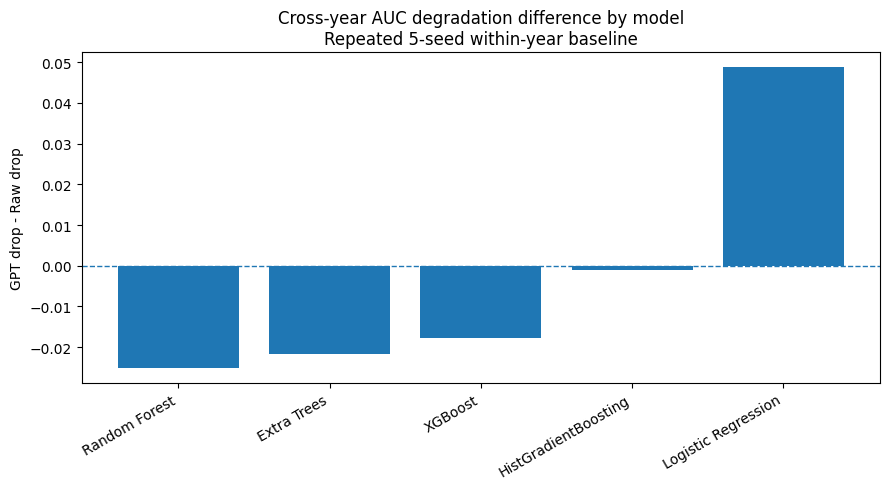

Saved: nsduh_analysis_outputs/cross_year_gpt_minus_raw_drop_difference_by_model.png


In [19]:
# plot 1
import matplotlib.pyplot as plt
import numpy as np

plot_df = drop_repeated_summary.copy()

plot_df = plot_df.sort_values("GPT_drop_minus_Raw_drop_mean")

plt.figure(figsize=(9, 5))

plt.bar(
    plot_df["Model"],
    plot_df["GPT_drop_minus_Raw_drop_mean"]
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.xticks(rotation=30, ha="right")
plt.ylabel("GPT drop - Raw drop")
plt.title("Cross-year AUC degradation difference by model\nRepeated 5-seed within-year baseline")

plt.tight_layout()

save_path = OUT_DIR / "cross_year_gpt_minus_raw_drop_difference_by_model.png"
plt.savefig(save_path, dpi=300)
plt.show()

print("Saved:", save_path)

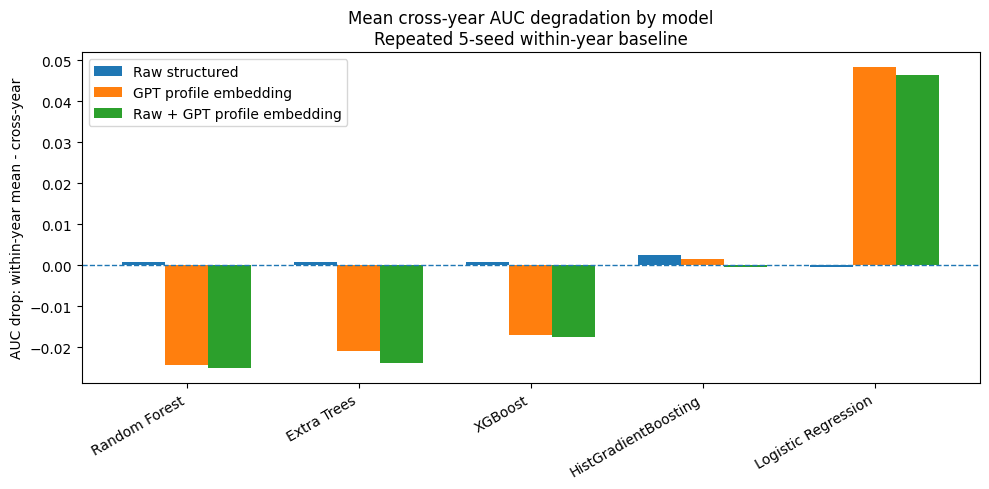

Saved: nsduh_analysis_outputs/cross_year_auc_drop_by_model_repeated_5seeds.png


In [20]:
plot_df = drop_repeated_summary.copy()

models = plot_df["Model"].tolist()
x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10, 5))

plt.bar(
    x - width,
    plot_df["Raw_drop_mean"],
    width,
    label="Raw structured"
)

plt.bar(
    x,
    plot_df["GPT_drop_mean"],
    width,
    label="GPT profile embedding"
)

plt.bar(
    x + width,
    plot_df["Combined_drop_mean"],
    width,
    label="Raw + GPT profile embedding"
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.xticks(x, models, rotation=30, ha="right")
plt.ylabel("AUC drop: within-year mean - cross-year")
plt.title("Mean cross-year AUC degradation by model\nRepeated 5-seed within-year baseline")
plt.legend()

plt.tight_layout()

save_path = OUT_DIR / "cross_year_auc_drop_by_model_repeated_5seeds.png"
plt.savefig(save_path, dpi=300)
plt.show()

print("Saved:", save_path)

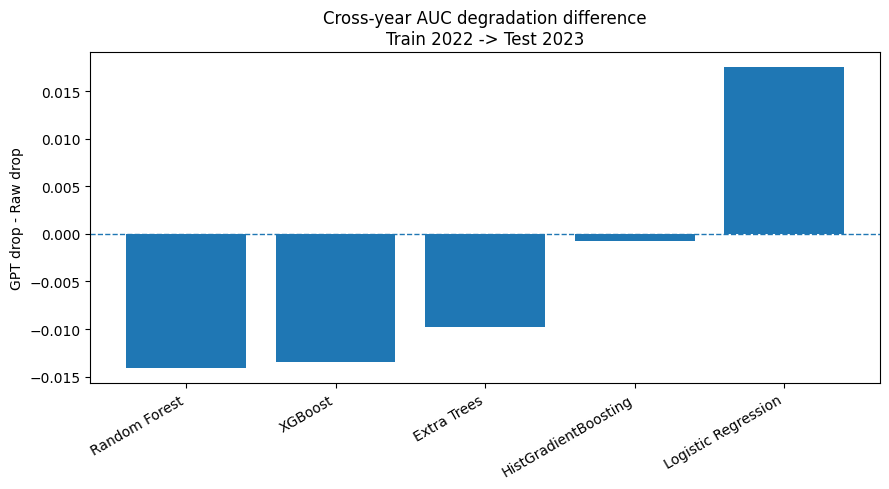

Saved: nsduh_analysis_outputs/cross_year_gpt_minus_raw_drop_difference_train_2022_to_test_2023.png


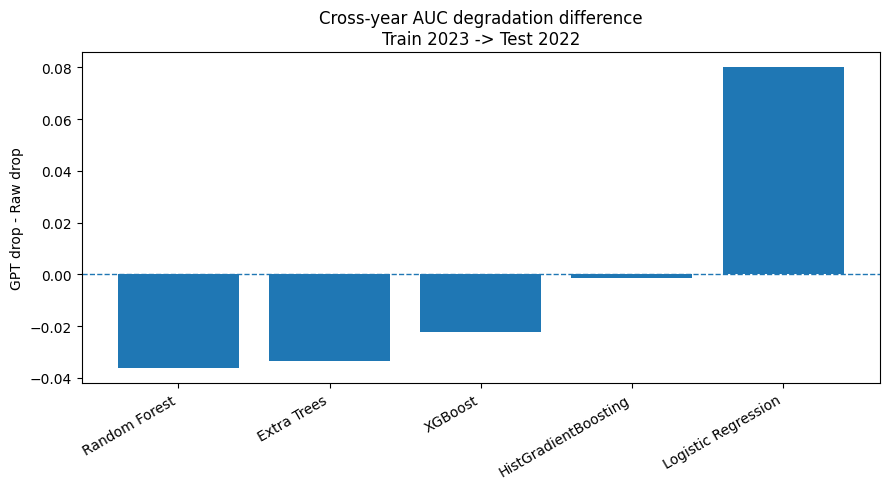

Saved: nsduh_analysis_outputs/cross_year_gpt_minus_raw_drop_difference_train_2023_to_test_2022.png


In [21]:
plot_df = drop_repeated_pivot.copy()

for exp_name in plot_df["Experiment"].unique():
    temp = plot_df[plot_df["Experiment"] == exp_name].copy()
    temp = temp.sort_values("GPT_drop_minus_Raw_drop")

    plt.figure(figsize=(9, 5))

    plt.bar(
        temp["Model"],
        temp["GPT_drop_minus_Raw_drop"]
    )

    plt.axhline(0, linestyle="--", linewidth=1)

    plt.xticks(rotation=30, ha="right")
    plt.ylabel("GPT drop - Raw drop")
    plt.title(f"Cross-year AUC degradation difference\n{exp_name}")

    plt.tight_layout()

    safe_name = (
        exp_name
        .replace(" ", "_")
        .replace("->", "to")
        .replace(">", "to")
        .lower()
    )

    save_path = OUT_DIR / f"cross_year_gpt_minus_raw_drop_difference_{safe_name}.png"
    plt.savefig(save_path, dpi=300)
    plt.show()

    print("Saved:", save_path)